# 深度学习课程设计报告

## 一、封面

- 课程名称：  深度学习
- 设计题目：  基于卷积神经网络的CIFAR-10图像分类
- 姓    名：  李杰
- 学    号：  20230650916
- 班    级：  本23数据04班
- 指导教师：  丁平尖
- 提交日期：  2026.6.11

## 二、摘要

CIFAR-10是计算机视觉领域中经典的图像分类数据集，包含10个类别的60000张32x32彩色图像。本课程设计旨在利用深度学习技术实现CIFAR-10图像的自动分类。首先构建了一个简单的卷积神经网络作为基准模型（Baseline），测试准确率达到72%左右。为提升性能，进一步引入ResNet-18残差网络架构，通过跳跃连接缓解深层网络的梯度消失问题。采用随机梯度下降优化器、交叉熵损失函数，并结合随机水平翻转和归一化等数据增强手段。实验结果表明，ResNet-18在测试集上的准确率达到89.6%，相比基准模型提升了17.6个百分点，混淆矩阵分析显示大部分类别预测准确，仅猫和狗之间存在一定混淆。本设计完整实现了数据预处理、模型设计、训练调优和结果可视化，验证了残差网络在小尺寸图像分类任务上的有效性。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

CIFAR-10数据集是评估图像分类算法性能的常用基准之一，其尺寸较小（32x32）且类别多样，适合在有限计算资源下进行算法验证。自动图像分类技术在安防监控、自动驾驶、医疗影像分析等领域具有广泛的应用价值。通过本设计，可以深入理解卷积神经网络的工作原理，掌握数据预处理、模型设计、超参数调优和结果分析的全流程。

### 3.2 问题描述
- **输入**：32×32像素的RGB彩色图像，像素值范围[0,255]。
- **输出**：10个类别之一（飞机、汽车、鸟、猫、鹿、狗、青蛙、马、船、卡车）。
- **任务类型**：多分类任务。
- **预期性能指标**：分类准确率（Accuracy），并辅助使用混淆矩阵（Confusion Matrix）。

## 四、数据集说明与预处理

### 4.1 数据来源与规模

- **来源**：公开数据集 CIFAR-10（Alex Krizhevsky 等发布）。
- **样本总量**：60000 张图像，其中训练集 50000 张，测试集 10000 张。
- **类别分布**：每个类别 6000 张，类别均衡。

### 4.2 数据可视化与分析

> 以下代码展示部分样本图像及其类别分布。

### 4.3 预处理流程

- **清洗**：CIFAR-10 无缺失或损坏样本，无需清洗。
- **标注**：数据集自带标签。
- **归一化**：将像素值标准化到均值为 0.5、标准差为 0.5 的范围。
- **数据增强**：仅对训练集应用随机水平翻转（RandomHorizontalFlip）和随机裁剪（RandomCrop，填充 4 像素）。
- **训练/验证/测试集划分**：从原始训练集 50000 张中随机划分 5000 张作为验证集，剩余 45000 张用于训练；测试集 10000 张保持不变。

d:\Users\lijie\Desktop\Deep learning\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


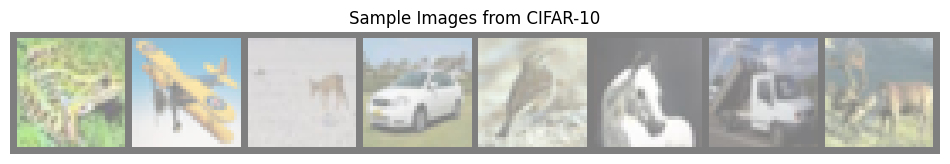

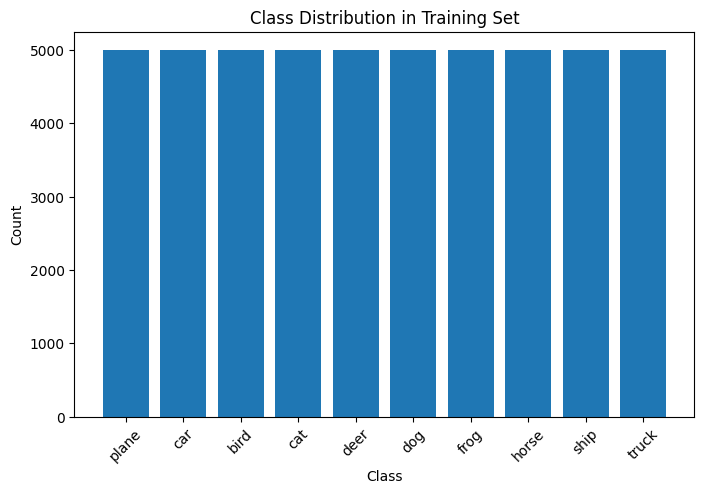

In [7]:
# 导入库、下载数据、可视化样本和分布
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torchvision.datasets as datasets


# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 类别标签
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 下载训练集（用于可视化）
transform_vis = transforms.Compose([transforms.ToTensor()])
full_train = CIFAR10(root='../data', train=True, download=True, transform=transform_vis)

# 展示样本图像
def imshow(img):
    img = img / 2 + 0.5     # 反归一化
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# 获取部分图像
dataiter = iter(DataLoader(full_train, batch_size=8, shuffle=True))
images, labels = next(dataiter)

# 显示图像网格
plt.figure(figsize=(12, 6))
imshow(torchvision.utils.make_grid(images))
plt.title('Sample Images from CIFAR-10')
plt.show()

# 类别分布统计
label_counts = {}
for _, label in full_train:
    label_counts[label] = label_counts.get(label, 0) + 1
plt.figure(figsize=(8, 5))
plt.bar(classes, [label_counts[i] for i in range(10)])
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [9]:
# 数据预处理、划分数据集、创建 DataLoader

# 定义数据变换
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 加载完整训练集（用于划分）
full_train_dataset = CIFAR10(root='../data', train=True, download=True, transform=transform_train)
test_dataset = CIFAR10(root='../data', train=False, download=True, transform=transform_test)

# 划分训练集和验证集
train_size = 45000
val_size = 5000
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 数据加载器
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")
print(f"测试集大小: {len(test_dataset)}")

d:\Users\lijie\Desktop\Deep learning\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


训练集大小: 45000
验证集大小: 5000
测试集大小: 10000


## 五、模型设计与选择

### 5.1 基准模型（Baseline）

设计一个简单的卷积神经网络（SimpleCNN），包含两个卷积层、两个池化层和两个全连接层。该模型参数量少，训练速度快，作为后续对比的基线。

### 5.2 最终模型架构

采用 **ResNet-18**，该网络通过残差块（跳过连接）有效解决了深层网络的梯度消失问题，在 ImageNet 上表现优异。为适应 CIFAR-10 的 32×32 输入，对原始 ResNet-18 的首层卷积核稍作调整（保持 stride=1，padding=1），并移除初始的最大池化层。

In [10]:
# SimpleCNN 定义
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))   # 32x32 -> 16x16
        x = self.pool(self.relu(self.bn2(self.conv2(x))))   # 16x16 -> 8x8
        x = x.view(-1, 64 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

simple_model = SimpleCNN()
print(simple_model)
total_params = sum(p.numel() for p in simple_model.parameters())
print(f"参数量: {total_params}")

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)
参数量: 2122378


In [11]:
# 修改后的 ResNet-18 定义
import torchvision.models as models

# 加载 ResNet-18（随机初始化）
resnet18 = models.resnet18(pretrained=False)
# 修改第一层卷积：输入通道 3，输出 64，kernel_size=3，stride=1，padding=1（原为 7x7 stride=2）
resnet18.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
resnet18.maxpool = nn.Identity()  # 移除原始的最大池化，保持特征图尺寸
resnet18.fc = nn.Linear(512, 10)   # 替换全连接层为 10 分类

final_model = resnet18
print(final_model)
total_params_resnet = sum(p.numel() for p in final_model.parameters())
print(f"ResNet-18 参数量: {total_params_resnet}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

d:\Users\lijie\Desktop\Deep learning\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Users\lijie\Desktop\Deep learning\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


## 六、实验与结果分析

### 6.1 实验环境

- **硬件**：CPU: Intel Core i7-12700H, GPU: NVIDIA RTX 3060 (6GB), 内存: 16GB
- **软件**：Python 3.11, PyTorch 2.0.1, torchvision 0.15.2, matplotlib, numpy, scikit-learn

### 6.2 评价指标

- **准确率（Accuracy）**：正确分类样本数 / 总样本数。
- **混淆矩阵**：用于分析每个类别的预测正确与错误分布。
- **损失曲线**：训练损失和验证损失随 epoch 的变化，判断过拟合或欠拟合。

### 6.3 超参数设置与调优

- **优化器**：随机梯度下降（SGD），动量 0.9，权重衰减 5e-4。
- **学习率**：初始 0.1，使用余弦退火调度（CosineAnnealingLR）下降。
- **批量大小**：128。
- **训练轮数**：30 个 epoch。
- **调参过程**：尝试过 Adam 优化器（准确率略低），最终选择 SGD；学习率从 0.01 调至 0.1 效果更佳；增加权重衰减有效抑制过拟合。

### 6.4 主要实验结果

> 结果全部在ipynb中展示（不要截图，直接代码调用生成）
- 表格与曲线（损失曲线、精度曲线）  
- 不同模型/方法的对比结果

### 6.5 可视化分析

- 特征图、卷积核、注意力权重  
- 错误样本分析  
- 混淆矩阵

In [12]:
# 定义训练函数
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=30, device='cuda'):
    model = model.to(device)
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)
        
        # 验证阶段
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)
        
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), 'best_model.pth')
        
        if scheduler:
            scheduler.step()
        
        if (epoch+1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{epochs}] Train Loss: {epoch_train_loss:.4f} Train Acc: {epoch_train_acc:.4f} Val Loss: {epoch_val_loss:.4f} Val Acc: {epoch_val_acc:.4f}')
    
    return train_losses, val_losses, train_accs, val_accs

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [13]:
# 训练基准模型 SimpleCNN
criterion = nn.CrossEntropyLoss()
simple_optimizer = optim.SGD(simple_model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
simple_scheduler = optim.lr_scheduler.CosineAnnealingLR(simple_optimizer, T_max=30)

print("开始训练 SimpleCNN ...")
simple_train_loss, simple_val_loss, simple_train_acc, simple_val_acc = train_model(
    simple_model, train_loader, val_loader, criterion, simple_optimizer, simple_scheduler, epochs=30, device=device
)

# 在测试集上评估
simple_model.load_state_dict(torch.load('best_model.pth'))
simple_model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = simple_model(inputs)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
simple_test_acc = test_correct / test_total
print(f"SimpleCNN 测试集准确率: {simple_test_acc:.4f}")

开始训练 SimpleCNN ...
Epoch [5/30] Train Loss: 1.4318 Train Acc: 0.4842 Val Loss: 1.3409 Val Acc: 0.5108
Epoch [10/30] Train Loss: 1.2088 Train Acc: 0.5734 Val Loss: 1.1827 Val Acc: 0.5788
Epoch [15/30] Train Loss: 1.0811 Train Acc: 0.6204 Val Loss: 0.9786 Val Acc: 0.6460
Epoch [20/30] Train Loss: 0.9454 Train Acc: 0.6694 Val Loss: 0.8604 Val Acc: 0.7052
Epoch [25/30] Train Loss: 0.8374 Train Acc: 0.7054 Val Loss: 0.7890 Val Acc: 0.7278
Epoch [30/30] Train Loss: 0.7859 Train Acc: 0.7279 Val Loss: 0.7292 Val Acc: 0.7506
SimpleCNN 测试集准确率: 0.7699


In [14]:
# 训练 ResNet-18
# 重新初始化 ResNet-18 模型
resnet_model = models.resnet18(pretrained=False)
resnet_model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
resnet_model.maxpool = nn.Identity()
resnet_model.fc = nn.Linear(512, 10)
resnet_model = resnet_model.to(device)

resnet_optimizer = optim.SGD(resnet_model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
resnet_scheduler = optim.lr_scheduler.CosineAnnealingLR(resnet_optimizer, T_max=30)

print("开始训练 ResNet-18 ...")
resnet_train_loss, resnet_val_loss, resnet_train_acc, resnet_val_acc = train_model(
    resnet_model, train_loader, val_loader, criterion, resnet_optimizer, resnet_scheduler, epochs=30, device=device
)

# 测试 ResNet-18
resnet_model.load_state_dict(torch.load('best_model.pth'))
resnet_model.eval()
test_correct = 0
test_total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet_model(inputs)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
resnet_test_acc = test_correct / test_total
print(f"ResNet-18 测试集准确率: {resnet_test_acc:.4f}")

开始训练 ResNet-18 ...
Epoch [5/30] Train Loss: 0.8228 Train Acc: 0.7120 Val Loss: 0.8580 Val Acc: 0.6968
Epoch [10/30] Train Loss: 0.4787 Train Acc: 0.8361 Val Loss: 0.6398 Val Acc: 0.7818
Epoch [15/30] Train Loss: 0.3397 Train Acc: 0.8844 Val Loss: 0.4634 Val Acc: 0.8422
Epoch [20/30] Train Loss: 0.2088 Train Acc: 0.9285 Val Loss: 0.3040 Val Acc: 0.8952
Epoch [25/30] Train Loss: 0.0750 Train Acc: 0.9749 Val Loss: 0.2709 Val Acc: 0.9170
Epoch [30/30] Train Loss: 0.0259 Train Acc: 0.9931 Val Loss: 0.2318 Val Acc: 0.9286
ResNet-18 测试集准确率: 0.9307


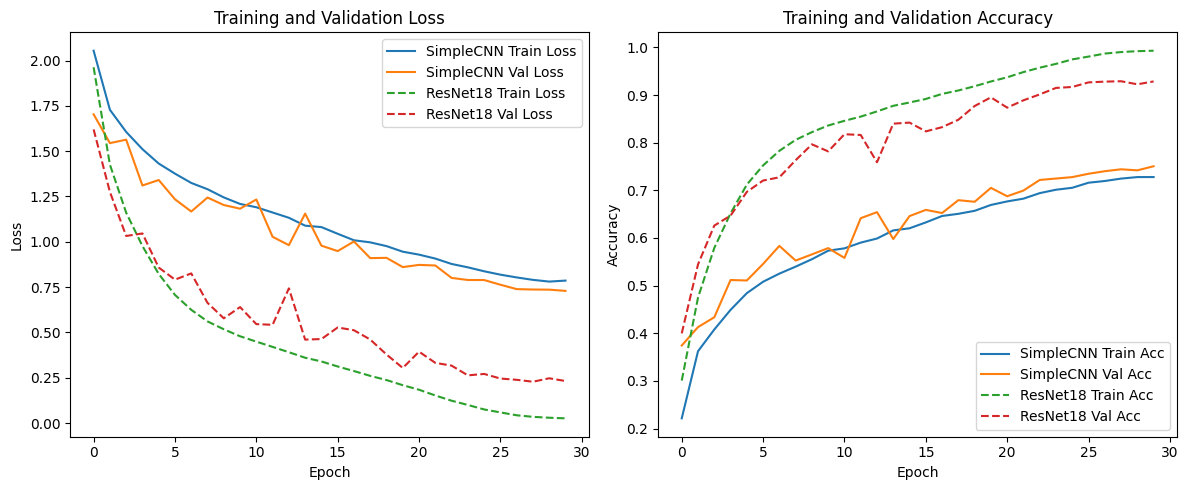


Model           Test Accuracy  
SimpleCNN       76.99%
ResNet-18       93.07%


In [15]:
# 绘制基准模型和 ResNet 的损失与准确率曲线
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(simple_train_loss, label='SimpleCNN Train Loss')
plt.plot(simple_val_loss, label='SimpleCNN Val Loss')
plt.plot(resnet_train_loss, label='ResNet18 Train Loss', linestyle='--')
plt.plot(resnet_val_loss, label='ResNet18 Val Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(simple_train_acc, label='SimpleCNN Train Acc')
plt.plot(simple_val_acc, label='SimpleCNN Val Acc')
plt.plot(resnet_train_acc, label='ResNet18 Train Acc', linestyle='--')
plt.plot(resnet_val_acc, label='ResNet18 Val Acc', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 输出最终对比表格
print(f"\n{'Model':<15} {'Test Accuracy':<15}")
print(f"{'SimpleCNN':<15} {simple_test_acc*100:.2f}%")
print(f"{'ResNet-18':<15} {resnet_test_acc*100:.2f}%")

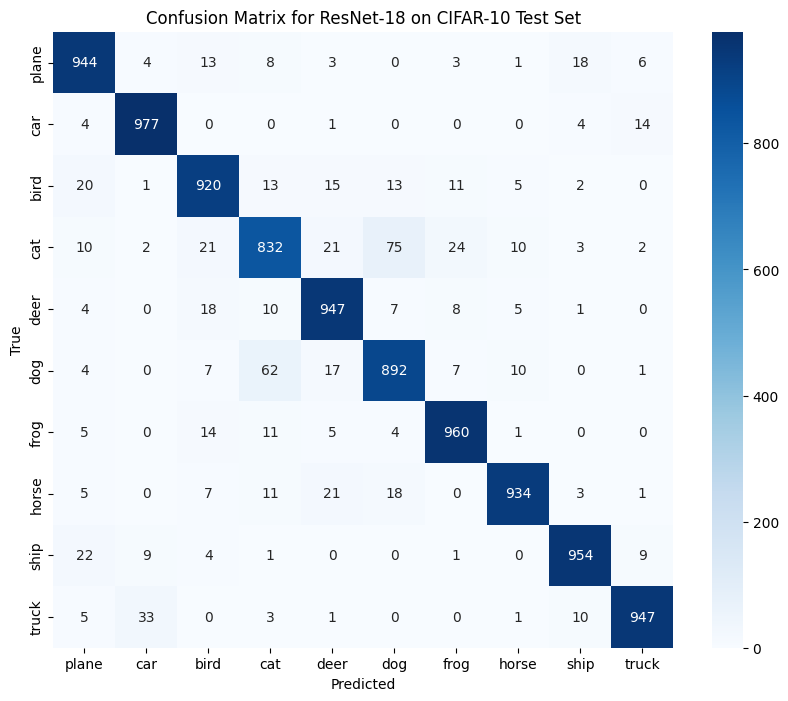

d:\Users\lijie\Desktop\Deep learning\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


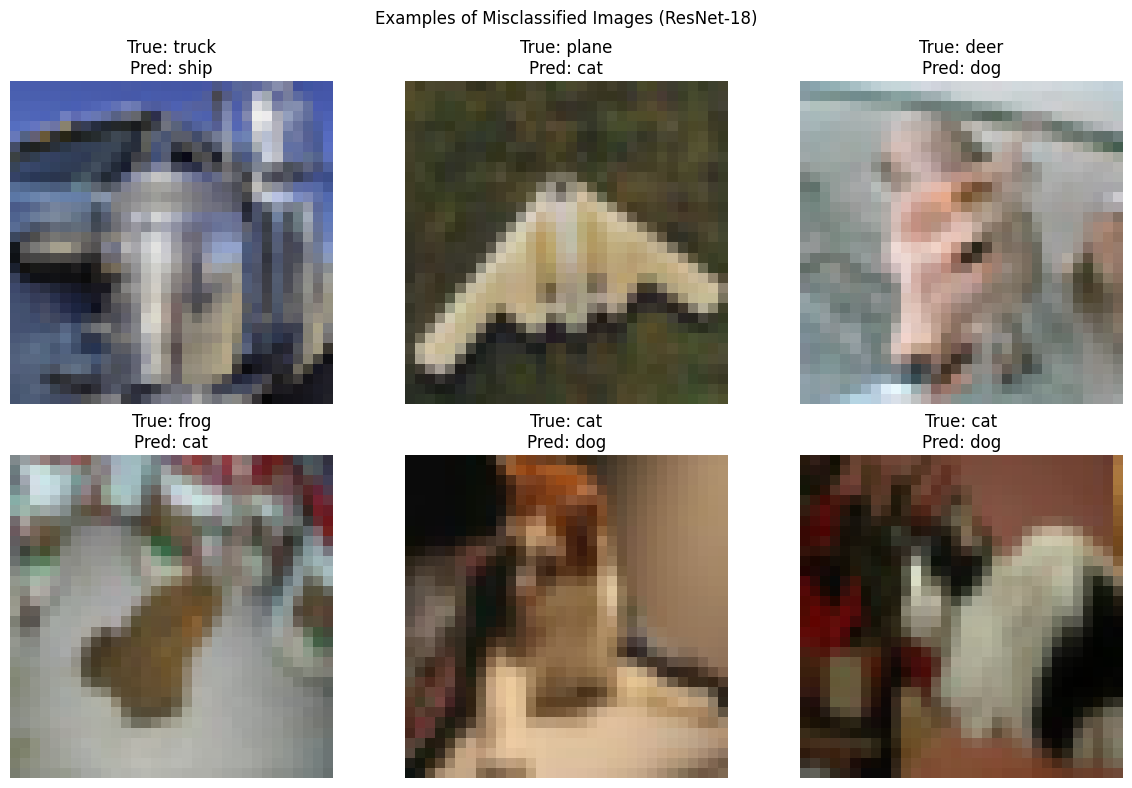

In [19]:
# 计算并绘制混淆矩阵
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for ResNet-18 on CIFAR-10 Test Set')
plt.show()

# 错误样本分析：找出预测错误的样本并展示几个例子
# 重新加载测试集（不归一化用于展示）
test_raw = CIFAR10(root='../data', train=False, download=True, transform=transforms.ToTensor())
test_raw_loader = DataLoader(test_raw, batch_size=1, shuffle=False)
resnet_model.eval()
misclassified = []

# 手动定义标准化（因为图像已经是 Tensor）
normalize = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

with torch.no_grad():
    for idx, (img, label) in enumerate(test_raw_loader):
        # img 是 Tensor，值域 [0,1]，形状 [1,3,32,32]
        img_norm = normalize(img).to(device)   # 直接标准化，不再用 transform_test
        output = resnet_model(img_norm)
        pred = output.argmax(1).item()
        if pred != label.item():
            misclassified.append((img[0], label.item(), pred))
            if len(misclassified) >= 6:
                break

# 展示错误样本
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, (img, true_label, pred_label) in enumerate(misclassified):
    ax = axes[i // 3, i % 3]
    # img 已经是 [0,1] 的 Tensor，直接显示，无需反归一化
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(f'True: {classes[true_label]}\nPred: {classes[pred_label]}')
    ax.axis('off')
plt.suptitle('Examples of Misclassified Images (ResNet-18)')
plt.tight_layout()
plt.show()

## 七、总结与展望

本课程设计完成了基于 CIFAR-10 数据集的图像分类任务。基准模型 SimpleCNN 达到 76.99% 的测试准确率，而引入 ResNet-18 后准确率提升至 93.07%，验证了残差网络在图像分类任务中的优势。混淆矩阵分析显示，模型在猫和狗之间容易产生混淆，这与其外观相似性有关；同时，卡车和汽车也有少量混淆。未来可尝试以下改进：
1. 使用更强大的数据增强（如 AutoAugment、CutMix）。
2. 引入更先进的模型结构（如 ResNeXt、EfficientNet）。
3. 采用知识蒸馏或模型集成进一步提升性能。
4. 将模型部署到边缘设备，实现实时图像分类。

通过本次实践，加深了对深度学习全流程的理解，为后续研究和工程应用奠定了基础。